<a href="https://colab.research.google.com/github/c3lttrong1a5ntduan-gif/retail-demand-forecasting-xai/blob/main/retail_demand_forecasting_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#I. General Preparation


In [5]:
import json
import numpy as np
import pandas as pd
import time
import warnings
from pathlib import Path
from scipy import stats


ROOT = Path('/content')
DATA = ROOT
RESULTS = ROOT / "results"
IMAGES = ROOT / "images"
RESULTS.mkdir(exist_ok=True)
IMAGES.mkdir(exist_ok=True)

H = 28
TARGET = "revenue"
SEED = 42


FOLDS = [("Fold 1", "2019-05-31", "2019-07-01", "2019-12-31"),
         ("Fold 2", "2020-05-31", "2020-07-01", "2020-12-31"),
         ("Fold 3", "2021-05-31", "2021-07-01", "2021-12-31")]
TEST_FOLD = ("TEST", "2022-05-31", "2022-07-01", "2022-12-31")
CV_FOLDS = ["Fold 2", "Fold 3"]

def split_by_date(df, train_end, valid_start, valid_end):
    """Split data into train and validation set ."""
    return (df[df.date <= train_end],
            df[(df.date >= valid_start) & (df.date <= valid_end)])

def metrics(y_true, y_pred):
    """WAPE is main metric."""
    y = np.asarray(y_true, float)
    p = np.clip(np.asarray(y_pred, float), 0, None)
    return dict(
        WAPE=float(np.sum(np.abs(y - p)) / np.sum(y)),
        bias=float((p.mean() - y.mean()) / y.mean()),
        R2=float(1 - np.sum((y - p) ** 2)
                 / np.sum((y - y.mean()) ** 2)))

def save_results(name, obj):

    text = json.dumps(obj, ensure_ascii=False, indent=2,
                      default=lambda o: o.tolist())
    open(f"{name}.json", "w", encoding="utf-8").write(text)

def load_results(name):
    return json.loads(open(f"{name}.json", encoding="utf-8").read())

In [6]:
def get_models(seed = SEED):
  from sklearn.tree import DecisionTreeRegressor
  from sklearn.ensemble import (RandomForestRegressor,
                                GradientBoostingRegressor)
  import lightgbm as lgb
  import xgboost as xgb

  boosting = dict(n_estimators = 700, learning_rate = 0.04,
                  subsample = 0.85, colsample_by_tree = 0.85,
                  reg_lambda = 0.01, n_jobs = -1, random_state = seed)

  return {
 "DecisionTree": DecisionTreeRegressor(
    max_depth=8, min_samples_leaf=15, random_state=seed),
 "RandomForest": RandomForestRegressor(
    n_estimators=400, max_depth=14, min_samples_leaf=3,
    n_jobs=-1, random_state=seed),
 "GradientBoosting": GradientBoostingRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=4,
    subsample=0.85, random_state=seed),
 "XGBoost": xgb.XGBRegressor(
    max_depth=5, tree_method="hist", **boosting),
 "LightGBM": lgb.LGBMRegressor(
    num_leaves=31, min_child_samples=20, subsample_freq=5,
    verbose=-1, **boosting),
 }

#II. Data Analysis

In [71]:
R = {"checks": []}

def check(name, passed, detail):
    """Record for a check. passed = True means data get passed, no need to fix."""
    R["checks"].append({"name": name, "passed": bool(passed), "detail": detail})
    print(f"  {'Pass ' if passed else 'Fail'}  {name:30s} {detail}")
    return passed

raw = pd.read_csv(DATA / "sales.csv", dtype=str)
date_text = raw.Date.astype(str).str.strip()

print("II  Data Analysis")
print(f"  File sales.csv: {len(raw):,} rows, {raw.shape[1]} columns")
print(f"  Column names : {', '.join(raw.columns)}")

II  Data Analysis
  File sales.csv: 3,851 rows, 3 columns
  Column names : Date, Revenue, COGS


In [72]:
raw.head(10)

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.9,1808622.79
5,2012-07-09,3548386.46,2787841.68
6,2012-07-10,5234938.62,4044438.84
7,2012-07-11,5582884.78,4338313.07
8,2012-07-12,5734632.02,4458811.27
9,2012-07-13,5309511.71,4143402.78


## Checking Data Type

In [73]:
type_report = {}
for column in ("Revenue", 'COGS'):
  n_bad = int(pd.to_numeric(raw[column], errors='coerce').isna().sum())
  type_report[column] = n_bad
  check(f'{column} can be read as number', n_bad == 0, f"{n_bad:,} records cant be read")

bad_value = pd.to_numeric(raw["Revenue"], errors = 'coerce').isna()
if bad_value.any():
    print("\n  3 first record cant be read:")
    for value in raw.loc[bad_value, "Revenue"].head(3):
        print(f"    {value!r}")
    extra = sorted(set("".join(raw.loc[bad_value, "Revenue"])) - set("0123456789."))
    print(f"  Only non-numeric character found in those cells: {extra} (thousand separator).")
    print("  A single uncastable cell forces the entire column to remain an object type, "
      "causing all downstream mathematical operations to fail.")
    R["extra_characters"] = extra
R["type_check"] = type_report


  Fail  Revenue can be read as number  308 records cant be read
  Fail  COGS can be read as number     308 records cant be read

  3 first record cant be read:
    '4,612,623.19'
    '1,204,115.66'
    '2,971,078.12'
  Only non-numeric character found in those cells: [','] (thousand separator).
  A single uncastable cell forces the entire column to remain an object type, causing all downstream mathematical operations to fail.


## Cheking Dt data type

In [74]:
has_slash = date_text.str.contains('/', na= False)
has_time = date_text.str.contains(':', na = False)
n_slash, n_time = int(has_slash.sum()), int(has_time.sum())

check("Number of date using same date type,", n_slash == 0,
      f"{n_slash:,} rows using slash, {len(raw) - n_slash} using hyphen ")

check("Date without time ", n_time == 0,
      f"{n_time:,} rows contain time")

form = (pd.Series(np.where(has_slash, "dd/mm/yyyy", "yyyy-mm-dd"), index=raw.index)
        + np.where(has_time, " hh:mm:ss", ""))
print("\n  All type in Date column:")
print(form.value_counts().to_string())

  Fail  Number of date using same date type, 213 rows using slash, 3638 using hyphen 
  Fail  Date without time              214 rows contain time

  All type in Date column:
yyyy-mm-dd             3485
yyyy-mm-dd hh:mm:ss     153
dd/mm/yyyy              152
dd/mm/yyyy hh:mm:ss      61


## Check if can remove time part

In [69]:
time_part = date_text[has_time].str.split().str[1]
all_midnight = bool((time_part == '00:00:00').all())
print(f"\n time part can be removed: {all_midnight}")

leading = date_text[has_slash].str.slice(0,2).astype(int)



R["date_format"] = {"slash": n_slash, "time": n_time,
                    "iso_plain": int((~has_slash & ~has_time).sum()),
                    "slash_and_time": int((has_slash & has_time).sum()),
                    "all_midnight": all_midnight,
                    "max_leading_number": int(leading.max())}


date_only = date_text.str.split().str[0]
parsed_date = pd.Series(pd.NaT, index=raw.index, dtype="datetime64[ns]")
parsed_date[has_slash] = pd.to_datetime(date_only[has_slash], format="%d/%m/%Y")
parsed_date[~has_slash] = pd.to_datetime(date_only[~has_slash], format="%Y-%m-%d")



 time part can be removed: False


## Checking Duplicates


In [12]:
is_duplicated = parsed_date.duplicated(keep= False)
n_duplicated_rows = int(is_duplicated.sum())
n_duplicated_days = int(parsed_date[is_duplicated].nunique())
check("No duplicated record", n_duplicated_rows == 0 ,
      f"{n_duplicated_days} days, {n_duplicated_rows} rows")
if n_duplicated_rows:
  same_values = raw.loc[is_duplicated, ["Revenue", 'COGS']].assign(
      d = parsed_date[is_duplicated]).duplicated(keep = False).all()
  print(f"\n All duplicated records have same values: {same_values}")
  R["duplicated_rows"] = bool(same_values)
R['duplicated'] = {'rows' : n_duplicated_rows, 'days' : n_duplicated_days}




  Fail  No duplicated record           18 days, 36 rows

 All duplicated records have same values: True


## Checking missing values

In [13]:
n_missing = raw.isna().sum().sum()
check("No missing value", n_missing == 0, f"{n_missing:,} missing values")
R['missing'] = n_missing

  Pass   No missing value               0 missing values


## Summary

In [75]:
failed = [c for c in R["checks"] if not c["passed"]]
print(f"  Run {len(R['checks'])} checks, {len(failed)} failed.\n")
for item in failed:
    print(f"  · {item['name']}: {item['detail']}")

print("\n  4 errors need to be fixed:")
R["n_failed"] = len(failed)

save_results("01_structure", R)

  Run 4 checks, 4 failed.

  · Revenue can be read as number: 308 records cant be read
  · COGS can be read as number: 308 records cant be read
  · Number of date using same date type,: 213 rows using slash, 3638 using hyphen 
  · Date without time : 214 rows contain time

  4 errors need to be fixed:


# III Data Cleaning

> Mandatory Order and Rationale:
>
>     III.1  Cast to numeric types       Values cannot be compared without proper numeric casting
>     III.2  Strip time components       Differences in time components prevent splitting two date formats
>     III.3  Standardize date formats    Duplicate rows cannot be identified without properly parsed dates
>     III.4  Aggregate duplicate dates
>     III.5  Re-verify / Audit



In [15]:
R = {}

raw = pd.read_csv(DATA / "sales.csv", dtype=str)
df = raw.rename(columns={"Date": "date", "Revenue": "revenue", "COGS": "cogs"})
n_input = len(df)

print("III  Data Cleaning")
print(f"  Read {n_input:,} rows from sales.csv")

III  Data Cleaning
  Read 3,851 rows from sales.csv


## III.1  Cast to numeric types

In [16]:
converted = {}

for column in ('revenue', 'cogs'):
  text = df[column].astype(str).str.strip()
  n_string = int(text.str.contains(',', regex = False).sum())
  df[column] = text.str.replace(',','', regex = False).astype(float)
  converted[column] = n_string
  print(f"  {column:8s}: stripped delimiters from {n_string:,} cells,"
      f" cast column type to {df[column].dtype}")

R["string_values"] = converted

print(f"  Re-checking value range: revenue from {df.revenue.min():,.0f}"
      f" to {df.revenue.max():,.0f}")
print("  If decimal points were accidentally stripped, the value range"
      " would jump to billions, making it immediately noticeable.")

  revenue : stripped delimiters from 308 cells, cast column type to float64
  cogs    : stripped delimiters from 308 cells, cast column type to float64
  Re-checking value range: revenue from 279,814 to 20,905,271
  If decimal points were accidentally stripped, the value range would jump to billions, making it immediately noticeable.


## III.2  Removing Time Part

In [17]:
date_text = df.date.astype(str).str.strip()
has_time = date_text.str.contains(':', na= False)
n_time = int(has_time.sum())

time_part = date_text[has_time].str.split().str[1]

distinct_time = sorted(time_part.unique())
print(f"  {n_time:,} rows contain time components, distinct values encountered: {distinct_time}")
assert distinct_time == ["00:00:00"], "non-zero time found, cannot strip"

date_text = date_text.str.split().str[0]
R["time_component"] = {"rows": n_time, "values": distinct_time}


  214 rows contain time components, distinct values encountered: ['00:00:00']


## III.3 STANDARDIZE DATE FORMATS

In [18]:
has_slash = date_text.str.contains("/", na=False)
n_slash = int(has_slash.sum())

parsed = pd.Series(pd.NaT, index=date_text.index, dtype="datetime64[ns]")
parsed[has_slash] = pd.to_datetime(date_text[has_slash], format="%d/%m/%Y")
parsed[~has_slash] = pd.to_datetime(date_text[~has_slash], format="%Y-%m-%d")
df["date"] = parsed

print(f"  Parsed {n_slash:,} rows as dd/mm/yyyy and {n_input - n_slash:,} rows as yyyy-mm-dd")
print(f"  Both groups now share a single unified format: yyyy-mm-dd")
print(f"  Time series spans from {df.date.min().date()} to {df.date.max().date()}")
R["date_format"] = {"slash": n_slash, "iso": n_input - n_slash}

df = df.sort_values("date").reset_index(drop=True)

  Parsed 213 rows as dd/mm/yyyy and 3,638 rows as yyyy-mm-dd
  Both groups now share a single unified format: yyyy-mm-dd
  Time series spans from 2012-07-04 to 2022-12-31


## III.4 Merge Duplicated Days

In [19]:
is_duplicated = df.date.duplicated(keep = False)
n_duplicated_rows = int(is_duplicated.sum())
n_duplicated_days = int(df.date[is_duplicated].nunique())
all_identical = bool(df[is_duplicated].duplicated(keep = False).all())
print(f"  Found {n_duplicated_days} duplicated days across {n_duplicated_rows} total rows")
print(f"  Duplicated rows have identical values: {all_identical}")

df = df.drop_duplicates(subset="date", keep="last").reset_index(drop=True)
print(f"  {len(df):,} rows remaining after deduplication")
R["duplicate"] = {"days": n_duplicated_days, "rows": n_duplicated_rows,
                  "identical": all_identical, "rows_after": len(df)}

  Found 18 duplicated days across 36 total rows
  Duplicated rows have identical values: True
  3,833 rows remaining after deduplication


## III.5 POST-PROCESSING DATA AUDIT

In [20]:
gap = df.date.diff().dropna().dt.days
checks = {
    "row count matches unique date count": len(df) == df.date.nunique(),
    "revenue column is float": df.revenue.dtype.kind == "f",
    "cogs column is float": df.cogs.dtype.kind == "f",
    "no missing values": int(df.isna().sum().sum()) == 0,
    "dates are strictly increasing": bool(df.date.is_monotonic_increasing),
    "continuous daily time series": bool((gap == 1).all()),
    "all revenue values are positive": bool((df.revenue > 0).all()),
}
for name, passed in checks.items():
    print(f"  {'PASS' if passed else 'FAIL'} {name}")
assert all(checks.values()), "post-processing audit failed"
R["post_checks"] = {k: bool(v) for k, v in checks.items()}

df.to_csv("sales_clean.csv", index=False)
R["n_input"] = n_input
R["n_output"] = len(df)
print(f"\n  {n_input:,} input rows, {len(df):,} output rows, saved to sales_clean.csv")
print(f"  Difference of {n_input - len(df)} rows matches merged duplicate count exactly")

save_results("02_clean", R)

  PASS row count matches unique date count
  PASS revenue column is float
  PASS cogs column is float
  PASS no missing values
  PASS dates are strictly increasing
  PASS continuous daily time series
  PASS all revenue values are positive

  3,851 input rows, 3,833 output rows, saved to sales_clean.csv
  Difference of 18 rows matches merged duplicate count exactly


# IV. Revenue Time Series Analysis


    IV.1  Annual Revenue Trend       Where to split the test set
    IV.2  Revenue Distribution       Apply log transformation or not, selection of evaluation metric
    IV.3  Outlier High-Revenue Days  Filter out or retain outliers
    IV.4  Seasonality Cycles         Which layer to incorporate calendar features into
    IV.5  Holidays, Promotions & COGS Which feature groups to keep, setting expectations
    IV.6  Autocorrelation by Lag     Which lag offsets are allowed for feature creation

In [21]:
R = {}

sales = pd.read_csv("sales_clean.csv", parse_dates=["date"])
revenue = sales.revenue

print(f"  Loaded {len(sales):,} rows from sales_clean.csv,"
      f" spanning from {sales.date.min().date()} to {sales.date.max().date()}")

  Loaded 3,833 rows from sales_clean.csv, spanning from 2012-07-04 to 2022-12-31


## IV.1 ANNUAL REVENUE TREND

In [22]:
by_year = sales.groupby(sales.date.dt.year)["revenue"].agg(daily_mean = "mean", n_days = 'count')
by_year["change_pct"] = by_year["daily_mean"].pct_change() * 100
print(by_year.round(1).rename_axis("year").to_string())

break_year = int(by_year.change_pct.idxmin())
break_pct = float(by_year.change_pct.min())
level_before = float(by_year.loc[2013:2018, 'daily_mean'].mean())
level_after = float(by_year.loc[2020:2022, 'daily_mean'].mean())

by_year_out = by_year.astype(object).where(by_year.notna(), None)
R["by_year"] = {int(year): row for year, row in by_year_out.to_dict("index").items()}
R["level_break"] = {"year": break_year, "drop_pct": break_pct,
                    "level_2013_2018": level_before, "level_2020_2022": level_after,
                    "ratio": level_before / level_after}
print(f"\n  Sharpest drop occurred in year {break_year} with {break_pct:.1f}%")
print(f"  2013 to 2018 period averaged {level_before:,.0f} per day")
print(f"  2020 to 2022 period averaged {level_after:,.0f} per day")
print(f"  Ratio of {level_before / level_after:.2f}x indicates the series regime has two distinct levels, not one")
print(f"\n  Year 2012 contains only {int(by_year.loc[2012, 'n_days'])} days, all in the second half of the year,")
print("  hence it cannot be directly compared with full years due to unequal time spans.")


      daily_mean  n_days  change_pct
year                                
2012   4096672.6     181         NaN
2013   4540190.2     365        10.8
2014   5128344.9     365        13.0
2015   5177900.9     365         1.0
2016   5750384.4     366        11.1
2017   5236066.6     365        -8.9
2018   5068828.6     365        -3.2
2019   3114524.5     365       -38.6
2020   2881180.8     366        -7.5
2021   2857643.3     365        -0.8
2022   3204791.3     365        12.1

  Sharpest drop occurred in year 2019 with -38.6%
  2013 to 2018 period averaged 5,150,286 per day
  2020 to 2022 period averaged 2,981,205 per day
  Ratio of 1.73x indicates the series regime has two distinct levels, not one

  Year 2012 contains only 181 days, all in the second half of the year,
  hence it cannot be directly compared with full years due to unequal time spans.


## IV.2 Revenue Distribution

In [23]:
n_negative = int((revenue < 0).sum())
n_zero = int((revenue == 0).sum())
print(f"  Negative revenue days: {n_negative}      Zero revenue days: {n_zero}")

skew_raw = float(stats.skew(revenue))
skew_log = float(stats.skew(np.log1p(revenue)))
print(f"\n  Raw scale skewness   : {skew_raw:+.3f}")
print(f"  log1p scale skewness : {skew_log:+.3f}")
print(f"  Max-to-median ratio  : {revenue.max() / revenue.median():.2f}x")
print(f"  Value range          : {revenue.min():,.0f} to {revenue.max():,.0f}")

R["distribution"] = {"skew": skew_raw, "skew_log1p": skew_log,
                     "max_over_median": float(revenue.max() / revenue.median()),
                     "cv": float(revenue.std() / revenue.mean()),
                     "n_negative": n_negative, "n_zero": n_zero,
                     "min": float(revenue.min()), "max": float(revenue.max()),
                     "median": float(revenue.median())}

print("  With such heavy right-skewness, standard RMSE is unsuitable"
      " as a few extreme outlier days will heavily dominate the overall loss.")




  Negative revenue days: 0      Zero revenue days: 0

  Raw scale skewness   : +1.669
  log1p scale skewness : -0.159
  Max-to-median ratio  : 5.73x
  Value range          : 279,814 to 20,905,271
  With such heavy right-skewness, standard RMSE is unsuitable as a few extreme outlier days will heavily dominate the overall loss.


## IV.3 OUTLIER HIGH-REVENUE DAYS

In [24]:
q1, q3 = revenue.quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
is_high = revenue > upper
is_low = revenue < q1 - 1.5 * (q3 - q1)

end_of_month = sales.date.dt.day.isin([29, 30, 31, 1, 2])
share_eom = float(end_of_month[is_high].mean())

print(f"  Upper Tukey threshold: {upper:,.0f}")
print(f"  Exceeding upper bound: {int(is_high.sum())} days ({100 * is_high.mean():.1f}%)")
print(f"  Below lower bound: {int(is_low.sum())} days")
print(f"  Share occurring on month-end cluster (days 29, 30, 31, 1, 2): {100 * share_eom:.1f}%")
print("\n  Top 3 highest revenue days:")
print(sales.nlargest(3, "revenue")[["date", "revenue"]].to_string(index=False))

R["outlier"] = {"threshold": float(upper), "n_high": int(is_high.sum()),
                "pct_high": float(100 * is_high.mean()), "n_low": int(is_low.sum()),
                "share_end_of_month": share_eom,
                "top3": [{"date": str(r.date.date()), "revenue": float(r.revenue)}
                         for r in sales.nlargest(3, "revenue").itertuples()]}

  Upper Tukey threshold: 9,670,560
  Exceeding upper bound: 169 days (4.4%)
  Below lower bound: 0 days
  Share occurring on month-end cluster (days 29, 30, 31, 1, 2): 63.9%

  Top 3 highest revenue days:
      date     revenue
2018-05-30 20905271.35
2018-05-31 19289944.12
2018-06-01 19245165.78


## IV.4 Seasonality Cycles

In [25]:
n_cycles = (sales.date.max() - sales.date.min()).days / 365.25
print(f"  Time series spans {n_cycles:.1f} annual cycles, sufficient for learning yearly seasonality")

sales["year_ratio"] = revenue / sales.groupby(sales.date.dt.year).revenue.transform("mean")
sales["month_ratio"] = revenue / sales.groupby(
    sales.date.dt.to_period("M")).revenue.transform("mean")

cycles = {}
for name, key in [("day_of_month", sales.date.dt.day),
                  ("month", sales.date.dt.month),
                  ("day_of_week", sales.date.dt.dayofweek)]:
    grouped = sales.groupby(key).year_ratio.mean()
    cycles[name] = {"peak_at": int(grouped.idxmax()), "peak": float(grouped.max()),
                    "trough_at": int(grouped.idxmin()), "trough": float(grouped.min()),
                    "amplitude": float(grouped.max() / grouped.min())}

print(pd.DataFrame(cycles).T.round(3)
      .astype({"peak_at": int, "trough_at": int}).rename_axis("cycle").to_string())
R["seasonality"] = cycles
R["n_year_cycles"] = float(n_cycles)

# Day 31 exists in only 7 out of 12 months, requiring cross-validation
is_31 = sales.date.dt.day == 31
R["day_31"] = {"by_year": float(sales.loc[is_31, "year_ratio"].mean()),
               "by_month": float(sales.loc[is_31, "month_ratio"].mean())}
print(f"\n  Day 31 exists in only 7 out of 12 months, requiring cross-validation:")
print(f"    Normalized by year : {R['day_31']['by_year']:.3f}")
print(f"    Normalized by month: {R['day_31']['by_month']:.3f}")

  Time series spans 10.5 annual cycles, sufficient for learning yearly seasonality
              peak_at   peak  trough_at  trough  amplitude
cycle                                                     
day_of_month       31  1.763          4   0.620      2.844
month               5  1.525         12   0.586      2.603
day_of_week         2  1.090          5   0.911      1.197

  Day 31 exists in only 7 out of 12 months, requiring cross-validation:
    Normalized by year : 1.763
    Normalized by month: 1.784


## IV.5 Holidays (Tet), Promotion, COGS

In [26]:
TET_DATES = ["2012-01-23", "2013-02-10", "2014-01-31", "2015-02-19",
 "2016-02-08", "2017-01-28", "2018-02-16", "2019-02-05",
 "2020-01-25", "2021-02-12", "2022-02-01", "2023-01-22"]

tet = pd.to_datetime(TET_DATES)
offset = np.stack([(sales.date - t).dt.days.values for t in tet])
sales['days_to_tet'] = offset[np.abs(offset).argmin(axis = 0), np.arange(len(sales))]

R["tet"] = {}
for name, lo, hi in [("30 to 15 days before", -30, -15),
                     ("14 to 1 day before", -14, -1),
                     ("Day 1 to Day 7 of Tet", 0, 7),
                     ("8 to 21 days after", 8, 21)]:
    window = sales.days_to_tet.between(lo, hi)
    R["tet"][name] = {"by_year": float(sales.loc[window, "year_ratio"].mean()),
                      "by_month": float(sales.loc[window, "month_ratio"].mean())}

print(pd.DataFrame(R["tet"]).T.round(3).rename_axis("window_around_tet").to_string())


                       by_year  by_month
window_around_tet                       
30 to 15 days before     0.604     1.014
14 to 1 day before       0.680     0.993
Day 1 to Day 7 of Tet    0.771     1.011
8 to 21 days after       0.826     0.959


**Promotion**

In [27]:
promotions = pd.read_csv(DATA / "promotions.csv", parse_dates=["start_date", "end_date"])
sales['has_promo'] = 0
for _, promo in promotions.iterrows():
    in_window = (sales.date >= promo.start_date) & (sales.date <= promo.end_date)
    sales.loc[in_window,'has_promo'] = 1
with_promo = sales.loc[sales.has_promo ==1 , 'month_ratio'].mean()
without_promo = sales.loc[sales.has_promo == 0, 'month_ratio'].mean()
covers = (promotions.start_date.min() <= sales.date.min() + pd.Timedelta(days=365)
          and promotions.end_date.max() >= sales.date.max() - pd.Timedelta(days=365))

R["promotion"] = {"n_programs": len(promotions),
                  "n_days_with": int((sales.has_promo == 1).sum()),
                  "ratio_with": float(with_promo), "ratio_without": float(without_promo),
                  "lift_pct": float(100 * (with_promo / without_promo - 1)),
                  "covers_series": bool(covers),
                  "first": str(promotions.start_date.min().date()),
                  "last": str(promotions.end_date.max().date())}

print(f"\n  {len(promotions)} promotion campaigns, spanning from {promotions.start_date.min().date()}"
      f" to {promotions.end_date.max().date()}")
print(f"    Days with promotion    : {with_promo:.3f}")
print(f"    Days without promotion : {without_promo:.3f}")
print(f"    Lift: {100 * (with_promo / without_promo - 1):+.1f}%, expected to have minor feature impact")



  50 promotion campaigns, spanning from 2013-01-31 to 2022-12-31
    Days with promotion    : 1.010
    Days without promotion : 0.992
    Lift: +1.9%, expected to have minor feature impact


**COGS and Negative Margin**

In [28]:
negative_margin = sales.cogs > revenue
quintile = pd.qcut(revenue, 5, labels=False)
share_by_quintile = (sales.assign(q=quintile, neg=negative_margin)
                     .groupby("q", observed=True).neg.mean() * 100)

R["cogs"] = {"correlation": float(revenue.corr(sales.cogs)),
             "mean_margin": float((1 - sales.cogs / revenue).mean()),
             "n_negative_margin": int(negative_margin.sum()),
             "pct_negative_margin": float(100 * negative_margin.mean()),
             "deepest": float((1 - sales.cogs / revenue).min()),
             "share_by_quintile": [float(v) for v in share_by_quintile]}

print(f"\n  COGS correlates strongly with revenue at {revenue.corr(sales.cogs):.4f}, but is recorded on the same day")
print(f"\n  Negative margin days: {int(negative_margin.sum())}"
      f" ({100 * negative_margin.mean():.1f}%), deepest negative margin: {(1 - sales.cogs / revenue).min():.3f}")
print("    " + "   ".join(f"{v:.1f}%" for v in share_by_quintile))


  COGS correlates strongly with revenue at 0.9760, but is recorded on the same day

  Negative margin days: 382 (10.0%), deepest negative margin: -0.575
    21.4%   14.0%   7.4%   3.9%   3.1%


## IV.6 Autocorrelation By Lag

In [29]:
H = 28  # Forecasting horizon of 28 days

z = sales.year_ratio
lags = [1, 3, 7, 14, 21, 28, 35, 42, 56, 91, 182, 273, 364, 371, 546, 728]
acf = {lag: float(z.autocorr(lag)) for lag in lags}
R["acf"] = acf

acf_table = pd.DataFrame({"acf": acf})
acf_table["status"] = np.where(acf_table.index >= H, "allowed", "blocked")
print(acf_table.round(3).rename_axis("lag").to_string())

allowed = {lag: value for lag, value in acf.items() if lag >= H}
best_lag = max(allowed, key=lambda k: abs(allowed[k]))
R["best_allowed_lag"] = {"lag": best_lag, "value": allowed[best_lag]}

print(f"\n  Strongest overall correlation is lag-1 at {acf[1]:.3f}, but it cannot be used")
print(f"  because when forecasting {H} days ahead, yesterday's actual revenue is unknown.")
print(f"  Strongest autocorrelation within the feasible region (lag >= {H}) is lag-{best_lag} at {allowed[best_lag]:.3f}.")

       acf   status
lag                
1    0.833  blocked
3    0.545  blocked
7    0.391  blocked
14   0.399  blocked
21   0.325  blocked
28   0.518  allowed
35   0.321  allowed
42   0.239  allowed
56   0.167  allowed
91   0.213  allowed
182 -0.184  allowed
273  0.194  allowed
364  0.751  allowed
371  0.353  allowed
546 -0.220  allowed
728  0.638  allowed

  Strongest overall correlation is lag-1 at 0.833, but it cannot be used
  because when forecasting 28 days ahead, yesterday's actual revenue is unknown.
  Strongest autocorrelation within the feasible region (lag >= 28) is lag-364 at 0.751.


### 6 Observations And Decions



In [30]:
decisions = [
    f"Revenue level regime shift occurred in year {break_year}, so the test set cutoff accounts for this structural break",
    f"Heavy right-skewed distribution with skewness {skew_raw:.3f} justifies using log1p transformation and WAPE evaluation metric",
    f"{int(is_high.sum())} high-revenue outlier days heavily cluster at month-ends, so they are retained without clipping",
    f"Day-of-month cycle shows strongest seasonality with amplitude {cycles['day_of_month']['amplitude']:.2f}x,"
    " requiring a countdown-to-month-end feature in the calendar group",
    "Tet holiday effect is largely captured as a monthly pattern, so the Tet feature group is kept with modest expectation",
    f"Lag-{best_lag} days is the strongest valid signal source, so history/lag features will center around this offset",
]
for i, line in enumerate(decisions, 1):
    print(f"  {i}. {line}")
R["decisions"] = decisions

save_results("03_analyze", R)

  1. Revenue level regime shift occurred in year 2019, so the test set cutoff accounts for this structural break
  2. Heavy right-skewed distribution with skewness 1.669 justifies using log1p transformation and WAPE evaluation metric
  3. 169 high-revenue outlier days heavily cluster at month-ends, so they are retained without clipping
  4. Day-of-month cycle shows strongest seasonality with amplitude 2.84x, requiring a countdown-to-month-end feature in the calendar group
  5. Tet holiday effect is largely captured as a monthly pattern, so the Tet feature group is kept with modest expectation
  6. Lag-364 days is the strongest valid signal source, so history/lag features will center around this offset


# SECTION V: FEATURE ENGINEERING

### Time Lag Constraint Rule
When forecasting for day $d$ with a forecast horizon $H$, the model is strictly limited to information available up to day $d - H$. All derived historical features from the target variable must be shifted back by at least $H$ days.

### Safe Implementation Strategy
Construct a base shifted series ($y_{base} = y_{t-H}$) first, then compute all rolling aggregations directly on top of this shifted base. The safety mechanism does not rely on the execution order of `.shift()` and `.rolling()` (which yield identical numerical results), but rather enforces an architectural pattern that prevents accidental omission of the required horizon shift.

### Feature Architecture Overview
Four distinct feature groups engineered based on Section IV analysis:
1. **Revenue History Group (24 columns)**: Centered around valid lag offsets where lag-364 (ACF = 0.751) serves as the strongest available annual signal.
2. **Calendar Group (19 columns)**: Capturing multi-tiered seasonality (day-of-week, day-of-month, month-of-year) which is deterministic and known in advance.
3. **Tet & Special Days Group (4 columns)**: Accounting for Lunar Calendar shifts using external reference tables.
4. **Promotion Group (6 columns)**: Derived from pre-announced campaign schedules, making them fully available within the forecast horizon $H$.

In [31]:
R = {}

raw = pd.read_csv(DATA / "sales_clean.csv", parse_dates=["date"]).sort_values("date")
raw = raw.reset_index(drop=True)

print("SECTION V: FEATURE ENGINEERING")
print(f"  Loaded {len(raw):,} rows from sales_clean.csv,"
      f" spanning from {raw.date.min().date()} to {raw.date.max().date()}")
print(f"  Forecast horizon H = {H} days")

SECTION V: FEATURE ENGINEERING
  Loaded 3,833 rows from sales_clean.csv, spanning from 2012-07-04 to 2022-12-31
  Forecast horizon H = 28 days


## V.1: Temporal Lag Constraint

In [32]:
print(f"  When forecasting for day d, the model only has access to data up to day d-{H}.")
print(f"  All target-derived history features must be shifted back by at least {H} days.")

# Illustration: Four leaky implementation patterns versus the leak-free safe pattern
y = raw[TARGET]
writing_styles = {
    "y.rolling(28).mean()":                     y.rolling(28).mean(),
    "y.shift(1).rolling(28).mean()":            y.shift(1).rolling(28).mean(),
    "y.shift(7).rolling(28).mean()":            y.shift(7).rolling(28).mean(),
    "y.rolling(28, center=True).mean().shift(28)": y.rolling(28, center=True).mean().shift(28),
    "y.shift(28).rolling(28).mean() (safe)":    y.shift(28).rolling(28).mean(),
}

  When forecasting for day d, the model only has access to data up to day d-28.
  All target-derived history features must be shifted back by at least 28 days.


In [33]:
b = raw.copy()
b.loc[b.index[-(H - 1):], TARGET] *= 9.3
yb = b[TARGET]

writing_styles_broken = {
    "y.rolling(28).mean()":                     yb.rolling(28).mean(),
    "y.shift(1).rolling(28).mean()":            yb.shift(1).rolling(28).mean(),
    "y.shift(7).rolling(28).mean()":            yb.shift(7).rolling(28).mean(),
    "y.rolling(28, center=True).mean().shift(28)": yb.rolling(28, center=True).mean().shift(28),
    "y.shift(28).rolling(28).mean() (safe)":    yb.shift(28).rolling(28).mean(),
}

change = pd.Series({name: abs(float(writing_styles[name].iloc[-1])
                             - float(writing_styles_broken[name].iloc[-1]))
                   for name in writing_styles})

R["writing_styles"] = change.to_dict()

print(pd.DataFrame({"last_row_response": change,
                    "verdict": np.where(change < 1e-9, "SAFE", "LEAK")})
      .to_string(float_format="{:.3e}".format))

print(f"\n  shift(28).rolling() yields identical results. The determining factor is whether the lag offset >= {H}.")

                                             last_row_response verdict
y.rolling(28).mean()                                 1.442e+07    LEAK
y.shift(1).rolling(28).mean()                        1.371e+07    LEAK
y.shift(7).rolling(28).mean()                        9.337e+06    LEAK
y.rolling(28, center=True).mean().shift(28)          5.110e+06    LEAK
y.shift(28).rolling(28).mean() (safe)                0.000e+00    SAFE

  shift(28).rolling() yields identical results. The determining factor is whether the lag offset >= 28.


## V.2 FEATURE GROUPS — REVENUE HISTORY GROUP

In [34]:
def add_lag_features(df, col = TARGET):
  y = df[col]
  safe = y.shift(H)
  for lag in (28, 35, 42, 56, 91, 182, 364, 371):
    df[f"lag_{lag}"] = y.shift(lag)

  for w in (7,28,91,364):
    df[f"roll_mean_{w}"] = safe.rolling(w, min_periods=max(2, w // 4)).mean()
    df[f"roll_std_{w}"] = safe.rolling(w, min_periods=max(2, w // 4)).std()

  df["roll_min_91"] = safe.rolling(91,min_periods=20).min()
  df["roll_max_91"] = safe.rolling(91,min_periods=20).max()

  df["lag364_smooth7"] = y.shift(364 - 3).rolling(7, min_periods=3).mean()
  df["lag364_smooth28"] = y.shift(364 - 14).rolling(28, min_periods=10).mean()


  df["ratio_28_364"] = df.roll_mean_28 / df.roll_mean_364
  df["ratio_91_364"] = df.roll_mean_91 / df.roll_mean_364
  df["trend_28_91"] = df.roll_mean_28 - df.roll_mean_91
  df["cv_91"] = df.roll_std_91 / df.roll_mean_91
  return df


**Holiday and special day features**

In [35]:
RETAIL_SPECIAL_DAYS = [(1, 1), (3, 8), (4, 30), (5, 1), (9, 2),
 (10, 20), (11, 11), (12, 12), (12, 24), (12, 25)]

def add_tet_features(df):

    d = df["date"]
    tet = pd.to_datetime(pd.Series(TET_DATES))
    diff = np.stack([(d - t).dt.days.values for t in tet])
    df["days_to_tet"] = diff[np.abs(diff).argmin(axis=0), np.arange(len(df))]
    df["tet_before"] = df.days_to_tet.between(-30, -1).astype("int8")
    df["tet_after"] = df.days_to_tet.between(0, 14).astype("int8")
    sp = set(RETAIL_SPECIAL_DAYS)
    df["is_special_day"] = np.array([(m, dd) in sp for m, dd in
                                     zip(d.dt.month, d.dt.day)], dtype="int8")
    return df

**Three-tiered seasonality features (deterministic & known in advance).**

In [36]:
def add_calendar_features(df):
    d = df["date"]
    df["dow"] = d.dt.dayofweek
    df["dom"] = d.dt.day
    df["month"] = d.dt.month
    df["quarter"] = d.dt.quarter
    df["doy"] = d.dt.dayofyear
    df["days_in_month"] = d.dt.days_in_month
    df["dom_reverse"] = df.days_in_month - df.dom       # 0 = ngày cuối tháng
    df["is_weekend"] = (df.dow >= 5).astype("int8")
    df["is_eom"] = (df.dom_reverse <= 3).astype("int8")
    df["is_som"] = (df.dom <= 2).astype("int8")
    df["is_odd_year"] = (d.dt.year % 2).astype("int8")
    for k in (1, 2, 3, 4):
        df[f"fourier_sin{k}"] = np.sin(2 * np.pi * k * df.doy / 365.25)
        df[f"fourier_cos{k}"] = np.cos(2 * np.pi * k * df.doy / 365.25)
    return df



** Promotion features (calendar public so known in advance)**

In [37]:
def add_promo_features(df):
    """
    Engineers promotional features from external promotion calendar.
    Since promotional campaigns are pre-announced, these features are fully valid
    for future forecasting horizons without data leakage.
    """
    pr = pd.read_csv(DATA / "promotions.csv", parse_dates=["start_date", "end_date"])
    df["promo_n"], df["promo_disc_max"], df["promo_day_idx"] = 0, 0.0, -1
    df["promo_streetwear"], df["promo_outdoor"] = 0, 0

    for _, p in pr.iterrows():
        m = (df.date >= p.start_date) & (df.date <= p.end_date)
        if not m.any():
            continue

        df.loc[m, "promo_n"] += 1
        df.loc[m, "promo_disc_max"] = np.maximum(
            df.loc[m, "promo_disc_max"], float(p.discount_value)
        )

        # Handle overlapping campaigns: retain the most recent campaign start day index
        # to ensure deterministic output independent of CSV row ordering
        idx = (df.loc[m, "date"] - p.start_date).dt.days
        cur = df.loc[m, "promo_day_idx"]
        df.loc[m, "promo_day_idx"] = np.where(cur < 0, idx, np.minimum(cur, idx))

        if p.applicable_category == "Streetwear":
            df.loc[m, "promo_streetwear"] = 1
        elif p.applicable_category == "Outdoor":
            df.loc[m, "promo_outdoor"] = 1

    df["promo_any"] = (df.promo_n > 0).astype("int8")
    return df

In [38]:
df = add_promo_features(add_tet_features(add_calendar_features(
    add_lag_features(raw.copy()))))
features = [c for c in df.columns if c not in ("date", TARGET, "cogs")]

GROUPS = {
    "revenue history": ("lag", "roll", "ratio", "trend", "cv_"),
    "calendar": ("dow", "dom",  "month", "quarter", "doy", "days_in", "is_week",
                 "is_eom", "is_som", "is_odd", "fourier"),
    "tet & special days": ("days_to_tet", "tet_", "is_special"),
    "promotions": ("promo",),
}

R["groups"] = {}
for name, prefixes in GROUPS.items():
    columns = [c for c in features if c.startswith(prefixes)]
    R["groups"][name] = {"n_columns": len(columns), "columns": columns}
    print(f"  {name:24s} {len(columns):3d} columns   {', '.join(columns[:4])} ...")

R["n_features"] = len(features)
print(f"  {'TOTAL':24s} {len(features):3d} columns")

# Assert that every feature is categorized without duplication or omission
assert sum(v["n_columns"] for v in R["groups"].values()) == len(features), "Feature group count mismatch: Some features were unassigned or misclassified!"

  revenue history           24 columns   lag_28, lag_35, lag_42, lag_56 ...
  calendar                  19 columns   dow, dom, month, quarter ...
  tet & special days         4 columns   days_to_tet, tet_before, tet_after, is_special_day ...
  promotions                 6 columns   promo_n, promo_disc_max, promo_day_idx, promo_streetwear ...
  TOTAL                     53 columns


## Validate Data Leakage

In [39]:
def leakage_probe(raw, n_checks=8):
    """
    Destructive leakage probe.

    For a prediction row at date d, modifying target labels in the window [d-H+1, d]
    must NOT alter any historical features at row d. Executed across multiple checkpoints
    to ensure edge-case leakages (which only appear when sufficient history exists)
    are properly caught rather than testing solely on the final row.
    """
    fa = add_lag_features(raw.copy())
    cols = [c for c in fa.columns if c.startswith(("lag", "roll", "ratio", "trend", "cv_"))]
    rows = np.linspace(max(H, 400), len(raw) - 1, n_checks, dtype=int)
    worst = 0.0

    for row in rows:
        b = raw.copy()
        # Perturb target labels in the blocked future horizon [row - H + 1 : row + 1]
        b.loc[b.index[row - H + 1 : row + 1], TARGET] *= 9.3
        fb = add_lag_features(b)

        # Calculate maximum absolute change between unperturbed and perturbed feature sets
        diff = (fa[cols].iloc[row].fillna(-1) - fb[cols].iloc[row].fillna(-1)).abs().max()
        worst = max(worst, float(diff))

    return worst, len(rows), len(cols)


worst, n_checkpoints, n_columns = leakage_probe(raw)
R["probe"] = {
    "max_change": worst,
    "n_checkpoints": n_checkpoints,
    "n_columns": n_columns
}

print(f"  Perturbed last {H} labels at {n_checkpoints} time checkpoints, "
      f"evaluating {n_columns} columns")
print(f"  Maximum observed variation = {worst:.3e}")

assert worst < 1e-9, "DATA LEAKAGE DETECTED: Features are looking ahead into blocked future labels!"

  Perturbed last 28 labels at 8 time checkpoints, evaluating 24 columns
  Maximum observed variation = 0.000e+00


**How metrics score change if data got leaked**

In [40]:
ready = df.dropna(subset=["lag_371", "roll_mean_364"]).reset_index(drop=True)
ready.to_csv(DATA / f"features_h{H}.csv", index=False)
ready = pd.read_csv(DATA / f"features_h{H}.csv", parse_dates=["date"])
train, test = split_by_date(ready, TEST_FOLD[1], TEST_FOLD[2], TEST_FOLD[3])
y_train_log = np.log1p(train[TARGET].values)
y_test = test[TARGET].values

**Train model twice, one column differ(['COGS'], causing data leakage)**

In [41]:
clean_model = get_models()["LightGBM"]
clean_model.fit(train[features], y_train_log)
m_clean = metrics(y_test, np.expm1(clean_model.predict(test[features])))

leaked_features = features + ["cogs"]
leaked_model = get_models()["LightGBM"]
leaked_model.fit(train[leaked_features], y_train_log)
m_leaked = metrics(y_test, np.expm1(leaked_model.predict(test[leaked_features])))

**Most important feature**

In [42]:
importance = pd.Series(leaked_model.feature_importances_,
                       index=leaked_features).sort_values(ascending=False)
cogs_correlation = float(df[TARGET].corr(df["cogs"]))

R["leak_demo"] = {
    "clean": m_clean,
    "leaked": m_leaked,
    "cogs_correlation": cogs_correlation,
    "top5_importance": {k: int(v) for k, v in importance.head(5).items()}
}

print(f"\n  Impact of Data Leakage: Training LightGBM twice on the training split of {TEST_FOLD[0]},")
print(f"  differing only by the inclusion of same-day 'cogs' feature.")
print(f"  Same-day correlation between 'cogs' and '{TARGET}' = {cogs_correlation:.4f}\n")

# Summary Comparison Table
comparison_df = pd.DataFrame({
    f"{len(features)} valid features": m_clean,
    "added same-day cogs (leaked)": m_leaked
}).T.round(4).rename_axis("feature set")

print(comparison_df.to_string())

print("\n  Top 5 feature importance rankings in the leaked model:")
print("  " + ", ".join(f"{k}={v}" for k, v in importance.head(5).items()))

print(f"\n  R2 spikes from {m_clean['R2']:.4f} up to {m_leaked['R2']:.4f}, "
      f"while WAPE drops from {m_clean['WAPE']:.4f} down to {m_leaked['WAPE']:.4f}.")
print(f"  Note: 'cogs' is only known post-transaction. In a true forecasting task, an R2 near 1.0 "
      f"dominated by a single same-day feature is a clear signature of data leakage.")


  Impact of Data Leakage: Training LightGBM twice on the training split of TEST,
  differing only by the inclusion of same-day 'cogs' feature.
  Same-day correlation between 'cogs' and 'revenue' = 0.9760

                                WAPE    bias      R2
feature set                                         
53 valid features             0.1961 -0.1118  0.6713
added same-day cogs (leaked)  0.0323  0.0200  0.9928

  Top 5 feature importance rankings in the leaked model:
  cogs=2823, lag_364=1252, lag_28=1132, lag_91=834, lag_371=817

  R2 spikes from 0.6713 up to 0.9928, while WAPE drops from 0.1961 down to 0.0323.
  Note: 'cogs' is only known post-transaction. In a true forecasting task, an R2 near 1.0 dominated by a single same-day feature is a clear signature of data leakage.


In [43]:
n_before = len(df)
# Drop initial warmup rows due to NaN values from long lag (lag_371) and rolling features (roll_mean_364)
df = df.dropna(subset=["lag_371", "roll_mean_364"]).reset_index(drop=True)

R["warmup"] = {
    "dropped": n_before - len(df),
    "remaining": len(df),
    "from": str(df.date.min().date()),
    "to": str(df.date.max().date()),
    "loss_pct": float(100 * (n_before - len(df)) / n_before)
}

print(f"  Dropped initial {n_before - len(df):,} days ({R['warmup']['loss_pct']:.1f}%) "
      f"due to NaNs from lag_371 & roll_mean_364 window warm-up.")
print(f"  Remaining: {len(df):,} daily observations, spanning from {df.date.min().date()} to {df.date.max().date()}.")
print(f"  Trade-off: Sacrificed {R['warmup']['loss_pct']:.1f}% of early history "
      f"to engineer exact same-period-last-year (SPLY) features.")

# Save final feature matrix to disk
output_filepath = DATA / f"features_h{H}.csv"
df.to_csv(output_filepath, index=False)

print(f"\n  Successfully exported {output_filepath} ({len(df):,} rows x {len(features)} features)")

R["features"] = features
save_results("04_features", R)

  Dropped initial 371 days (9.7%) due to NaNs from lag_371 & roll_mean_364 window warm-up.
  Remaining: 3,462 daily observations, spanning from 2013-07-10 to 2022-12-31.
  Trade-off: Sacrificed 9.7% of early history to engineer exact same-period-last-year (SPLY) features.

  Successfully exported /content/features_h28.csv (3,462 rows x 53 features)


# Section VI. Model Development

The development phase follows a strict 5-step sequential methodology:

* **VI.1 Time-Series Splitting Strategy**:
* **VI.2 Evaluation Metrics Selection**:
* **VI.3 Baseline Models Establishment**:
* **VI.4 Tree-Based Model Training**
* **VI.5 Feature Group Importance & Impact Analysis**

In [44]:
warnings.filterwarnings('ignore')
R = {}

df = pd.read_csv(DATA / f"features_h{H}.csv", parse_dates=["date"])
features = load_results('04_features')["features"]
series = df.set_index("date").revenue

CV_FOLDS = ["Fold 2", "Fold 3"]

def evaluate_fold(fold, columns, model = None):
  train, valid = split_by_date(df, fold[1], fold[2], fold[3])
  if model is None:
    model = get_models()["LightGBM"]
  model.fit(train[columns], np.log1p(train.revenue.values))
  prediction = np.expm1(model.predict(valid[columns]))
  return metrics(valid.revenue.values, prediction)

def cross_validate(columns, model_name = "LightGBM"):

  scores = {}
  for fold in FOLDS:
    model = get_models()[model_name]
    scores[fold[0]] = evaluate_fold(fold,columns,model)["WAPE"]
  scores["CV"] = float(np.mean([scores[f] for f in CV_FOLDS]))
  return scores

## VI.1 Time-Series Splitting

In [45]:
R["folds"] = []

for name,train_end,valid_start, valid_end in FOLDS + [TEST_FOLD]:
  train,valid = split_by_date(df, train_end, valid_start, valid_end)
  R["folds"].append({"name": name, "train_end": train_end,
                       "valid": f"{valid_start} đến {valid_end}",
                       "n_train": len(train), "n_valid": len(valid),
                       "buffer_days": (pd.Timestamp(valid_start)
                                       - pd.Timestamp(train_end)).days})

  print(pd.DataFrame(R["folds"]).to_string(index=False))
buffer_days = R["folds"][0]["buffer_days"]

print(f"\n  Buffer window: {buffer_days} days (exceeding the forecasting horizon H = {H}).")
print(f"  The gap buffer is strictly required because a training sample at date T is labeled")
print(f"  with revenue at T, whereas the first validation sample only has access to features up to T - {H}.")
print(f"\n  Note: Fold 1 falls directly on a period of structural demand shift and is isolated.")
print(f"  Final cross-validation metrics are averaged across the remaining folds.")

  name  train_end                     valid  n_train  n_valid  buffer_days
Fold 1 2019-05-31 2019-07-01 đến 2019-12-31     2152      184           31
  name  train_end                     valid  n_train  n_valid  buffer_days
Fold 1 2019-05-31 2019-07-01 đến 2019-12-31     2152      184           31
Fold 2 2020-05-31 2020-07-01 đến 2020-12-31     2518      184           31
  name  train_end                     valid  n_train  n_valid  buffer_days
Fold 1 2019-05-31 2019-07-01 đến 2019-12-31     2152      184           31
Fold 2 2020-05-31 2020-07-01 đến 2020-12-31     2518      184           31
Fold 3 2021-05-31 2021-07-01 đến 2021-12-31     2883      184           31
  name  train_end                     valid  n_train  n_valid  buffer_days
Fold 1 2019-05-31 2019-07-01 đến 2019-12-31     2152      184           31
Fold 2 2020-05-31 2020-07-01 đến 2020-12-31     2518      184           31
Fold 3 2021-05-31 2021-07-01 đến 2021-12-31     2883      184           31
  TEST 2022-05-31 2022-07

## VI.2 Choosing Metric (WAPE)

## VI.3 Baseline Models

In [46]:
# Level adjustment ratio: 91-day moving average growth rate compared to Same-Period-Last-Year (SPLY)
level_ratio = (
    series.shift(H).rolling(91).mean()
    / series.shift(364 + H).rolling(91).mean()
)

BASELINES = {
    "Naive Lag-28 y[d-28]": series.shift(H),
    "7-Day Moving Avg (Lag-28)": series.shift(H).rolling(7).mean(),
    "28-Day Moving Avg (Lag-28)": series.shift(H).rolling(28).mean(),
    "SPLY y[d-364]": series.shift(364),
    "SPLY 2-Year y[d-728]": series.shift(728),
    "2-Year SPLY Average": (series.shift(364) + series.shift(728)) / 2.0,
    "SPLY Level-Adjusted": series.shift(364) * level_ratio,
}

**Calc WAPE for each baseline model in each fold**

In [47]:
rows = []
for name, prediction in BASELINES.items():
    row = {"baseline": name}
    for fold in FOLDS + [TEST_FOLD]:
        _, valid = split_by_date(df, fold[1], fold[2], fold[3])
        p = np.nan_to_num(prediction.reindex(valid.date).values)
        row[fold[0]] = metrics(valid.revenue.values, p)["WAPE"]
    row["CV"] = float(np.mean([row[f] for f in CV_FOLDS]))
    rows.append(row)

table = pd.DataFrame(rows).set_index("baseline")
columns_shown = ["Fold 1", "Fold 2", "Fold 3", "CV", "TEST"]
print(table[columns_shown].round(4).rename_axis("Baseline Models").to_string())

                            Fold 1  Fold 2  Fold 3      CV    TEST
Baseline Models                                                   
Naive Lag-28 y[d-28]        0.4330  0.4080  0.4519  0.4299  0.4031
7-Day Moving Avg (Lag-28)   0.3856  0.3705  0.3660  0.3682  0.3574
28-Day Moving Avg (Lag-28)  0.4557  0.4558  0.4473  0.4515  0.4290
SPLY y[d-364]               0.6892  0.3362  0.3592  0.3477  0.2941
SPLY 2-Year y[d-728]        0.7597  0.7235  0.4109  0.5672  0.2847
2-Year SPLY Average         0.7052  0.4517  0.3410  0.3963  0.2428
SPLY Level-Adjusted         0.2872  0.3592  0.3853  0.3722  0.3105


**Choosing Models by Cross-Validation**

In [48]:
best_by_cv = table["CV"].idxmin()
best_by_test = table["TEST"].idxmin()

R["baselines"] = table[columns_shown].to_dict("index")
R["baseline_chosen"] = {
    "name": best_by_cv,
    "WAPE_cv": float(table.loc[best_by_cv, "CV"]),
    "WAPE_test": float(table.loc[best_by_cv, "TEST"])
}
R["baseline_trap"] = {
    "best_by_test": best_by_test,
    "WAPE_test": float(table.loc[best_by_test, "TEST"]),
    "WAPE_cv": float(table.loc[best_by_test, "CV"]),
    "best_by_cv": best_by_cv
}

print(f"\n  Selected via Cross-Validation: {best_by_cv}")
print(f"    CV WAPE = {table.loc[best_by_cv, 'CV']:.4f} | TEST WAPE = {table.loc[best_by_cv, 'TEST']:.4f}")

if best_by_test != best_by_cv:
    print(f"\n  Selection Trap Alert: Selecting by test set yields {best_by_test}")
    print(f"    TEST WAPE = {table.loc[best_by_test, 'TEST']:.4f}, but CV WAPE is {table.loc[best_by_test, 'CV']:.4f}")
    print("  Selecting models based on the test set reflects luck over a single window rather than a robust statistical pattern.")


  Selected via Cross-Validation: SPLY y[d-364]
    CV WAPE = 0.3477 | TEST WAPE = 0.2941

  Selection Trap Alert: Selecting by test set yields 2-Year SPLY Average
    TEST WAPE = 0.2428, but CV WAPE is 0.3963
  Selecting models based on the test set reflects luck over a single window rather than a robust statistical pattern.


## VI.4 Training Tree-based models

In [49]:
records = []
for fold in FOLDS:
    for model_name, model in get_models().items():
        started = time.time()
        score = evaluate_fold(fold, features, model)
        records.append(dict(fold=fold[0], model=model_name,
                            fit_seconds=time.time() - started, **score))
cv_table = pd.DataFrame(records)


In [50]:
cv_table

,fold,model,fit_seconds,WAPE,bias,R2
0,Fold 1,DecisionTree,0.110615,0.650405,0.615550,-2.389185
1,Fold 1,RandomForest,21.842249,0.518819,0.501523,-1.049752
2,Fold 1,GradientBoosting,20.666141,0.475763,0.433945,-0.742019
3,Fold 1,XGBoost,3.784371,0.504022,0.479062,-1.111852
4,Fold 1,LightGBM,2.516344,0.466801,0.451446,-0.703247
5,Fold 2,DecisionTree,0.087007,0.351531,-0.169726,0.214431
6,Fold 2,RandomForest,28.128266,0.263042,-0.112320,0.456114
7,Fold 2,GradientBoosting,26.431665,0.258976,-0.154759,0.475891
8,Fold 2,XGBoost,3.629507,0.255299,-0.128444,0.501123
9,Fold 2,LightGBM,6.912247,0.272169,-0.130936,0.446786


In [51]:
# Aggregate stable CV metrics across designated validation folds
stable = (cv_table[cv_table.fold.isin(CV_FOLDS)]
          .groupby("model")
          .agg(WAPE=("WAPE", "mean"),
               bias=("bias", "mean"),
               fit_seconds=("fit_seconds", "mean"))
          .sort_values("WAPE"))

# Isolate Fold 1 (anomalous fold) for comparison
fold1 = cv_table[cv_table.fold == "Fold 1"].set_index("model")

# Construct final summary table combining stable CV performance and Fold 1 behavior
summary = stable.assign(fold1_WAPE=fold1.WAPE, fold1_bias=fold1.bias)

print("\n  Cross-Validation & Model Efficiency Summary:")
print(summary.round(4)
      .rename(columns={"WAPE": "CV WAPE", "bias": "CV bias", "fit_seconds": "fit_time (s)",
                       "fold1_WAPE": "Fold 1 WAPE", "fold1_bias": "Fold 1 bias"})
      .rename_axis("model").to_string())

chosen_model = stable.index[0]
R["cv"] = summary.to_dict("index")
R["chosen_model"] = chosen_model

print(f"\n  Best Model Selected via CV: {chosen_model} (CV WAPE = {stable.WAPE.iloc[0]:.4f})")
print(f"  Structural Break Performance (Fold 1): WAPE = {fold1.loc[chosen_model, 'WAPE']:.4f} "
      f"| Bias = {fold1.loc[chosen_model, 'bias']:+.3f} (significant divergence from stable folds)")

# Histogram-based Gradient Boosting speedup analysis
slow = float(stable.loc["GradientBoosting", "fit_seconds"])
fast = float(stable.loc["LightGBM", "fit_seconds"])
R["histogram_speedup"] = slow / fast

print(f"\n  Histogram Algorithm Speedup: LightGBM took {fast:.1f}s vs GradientBoosting {slow:.1f}s "
      f"({slow / fast:.1f}x training speedup)")


  Cross-Validation & Model Efficiency Summary:
                  CV WAPE  CV bias  fit_time (s)  Fold 1 WAPE  Fold 1 bias
model                                                                     
GradientBoosting   0.2375  -0.0812       24.9069       0.4758       0.4339
XGBoost            0.2385  -0.0579        4.4282       0.5040       0.4791
LightGBM           0.2484  -0.0639        4.7066       0.4668       0.4514
RandomForest       0.2501  -0.0656       34.4009       0.5188       0.5015
DecisionTree       0.3153  -0.0899        0.1140       0.6504       0.6155

  Best Model Selected via CV: GradientBoosting (CV WAPE = 0.2375)
  Structural Break Performance (Fold 1): WAPE = 0.4758 | Bias = +0.434 (significant divergence from stable folds)

  Histogram Algorithm Speedup: LightGBM took 4.7s vs GradientBoosting 24.9s (5.3x training speedup)


## VI.5 Feature Group Importance and Impact Analysis

In [52]:
# Feature prefix groupings
HISTORY_PREFIXES = ("lag", "roll", "ratio", "trend", "cv_")
CALENDAR_PREFIXES = ("dow", "dom", "month", "quarter", "doy", "days_in", "is_week",
                     "is_eom", "is_som", "is_odd", "fourier")

# Incremental feature set tiers for ablation analysis
FEATURE_SETS = {
    "A. Raw Lags (2 Core Lags)": ["lag_28", "lag_364"],
    "B. All Raw Lags (8 Lags)": [c for c in features if c.startswith("lag_")],
    "C. Added Rolling Stats, Ratios & Trends": [c for c in features if c.startswith(HISTORY_PREFIXES)],
    "D. Added Calendar Signals & Fourier Terms": [c for c in features if c.startswith(HISTORY_PREFIXES + CALENDAR_PREFIXES)],
    "E. Full Feature Set (Added Holidays & Promo)": features,
}

**Run for each feature group**

In [53]:
rows = []
for name, columns in FEATURE_SETS.items():
    scores = cross_validate(columns)
    train, valid = split_by_date(df, *TEST_FOLD[1:])
    model = get_models()["LightGBM"]
    model.fit(train[columns], np.log1p(train.revenue.values))
    scores["TEST"] = metrics(valid.revenue.values,
                             np.expm1(model.predict(valid[columns])))["WAPE"]
    rows.append({"set": name, "n_columns": len(columns), **scores})

**result**

In [54]:
# Construct feature ablation evaluation summary table
add_table = pd.DataFrame(rows).set_index("set")
base_cv = add_table["CV"].iloc[0]

# Calculate relative improvement percentage compared to Minimal Baseline Tier A
add_table["vs_A_pct"] = 100 * (add_table["CV"] / base_cv - 1)

columns_mapping = {
    "n_columns": "num_features",
    "Fold 2": "Fold 2",
    "Fold 3": "Fold 3",
    "CV": "CV WAPE",
    "vs_A_pct": "vs_Set_A (%)",
    "TEST": "TEST WAPE"
}

print("\n  Incremental Feature Group Ablation Summary (LightGBM):")
print(add_table[list(columns_mapping.keys())].round(4)
      .rename(columns=columns_mapping)
      .rename_axis("feature set").to_string())

print(f"\n  Selected Non-ML Baseline ({R['baseline_chosen']['name']}): "
      f"CV WAPE = {R['baseline_chosen']['WAPE_cv']:.4f} | "
      f"TEST WAPE = {R['baseline_chosen']['WAPE_test']:.4f}")

# Save feature set metrics and net improvement percentage to global results
R["feature_sets"] = add_table.to_dict("index")
R["feature_total_gain_pct"] = float(100 * (1 - add_table["CV"].iloc[-1] / base_cv))

print(f"\n  Total Error Reduction: Adding full engineering features (Set A -> Set E) "
      f"reduced CV WAPE by {R['feature_total_gain_pct']:.2f}%")



  Incremental Feature Group Ablation Summary (LightGBM):
                                              num_features  Fold 2  Fold 3  CV WAPE  vs_Set_A (%)  TEST WAPE
feature set                                                                                                 
A. Raw Lags (2 Core Lags)                                2  0.3596  0.3980   0.3788        0.0000     0.3022
B. All Raw Lags (8 Lags)                                 8  0.3223  0.3162   0.3193      -15.7198     0.2353
C. Added Rolling Stats, Ratios & Trends                 24  0.3055  0.2663   0.2859      -24.5395     0.2711
D. Added Calendar Signals & Fourier Terms               43  0.2685  0.2585   0.2635      -30.4403     0.2082
E. Full Feature Set (Added Holidays & Promo)            53  0.2722  0.2247   0.2484      -34.4208     0.1961

  Selected Non-ML Baseline (SPLY y[d-364]): CV WAPE = 0.3477 | TEST WAPE = 0.2941

  Total Error Reduction: Adding full engineering features (Set A -> Set E) reduced CV WAPE by 3

**On Test Set**

In [55]:
# Check if TEST WAPE strictly decreases monotonically across feature tiers (A -> E)
monotone_test = bool((add_table["TEST"].diff().dropna() < 0).all())
R["feature_sets_monotone_test"] = monotone_test

print(f"\n  On Cross-Validation: CV WAPE strictly decreases from {base_cv:.4f} (Set A) "
      f"to {add_table['CV'].iloc[-1]:.4f} (Set E), representing a net error reduction of {R['feature_total_gain_pct']:.1f}%.")

if not monotone_test:
    # Identify the feature tier where TEST WAPE degraded relative to the previous tier
    worst = add_table["TEST"].diff().idxmax()
    previous = add_table.index[list(add_table.index).index(worst) - 1]

    print(f"\n  Test Set Variance Warning: Feature tier '{worst}' degraded on the test set "
          f"({add_table.loc[worst, 'TEST']:.4f} vs {add_table.loc[previous, 'TEST']:.4f} in '{previous}').")
    print("  Note: Minor non-monotonic fluctuations on a single test window are expected due to distribution shift.")

    R["feature_sets_warning"] = {
        "set": worst,
        "TEST": float(add_table.loc[worst, "TEST"]),
        "TEST_previous": float(add_table.loc[previous, "TEST"]),
        "CV": float(add_table.loc[worst, "CV"]),
        "CV_previous": float(add_table.loc[previous, "CV"])
    }

# Save section artifacts to global JSON results log
save_results("05_models", R)


  On Cross-Validation: CV WAPE strictly decreases from 0.3788 (Set A) to 0.2484 (Set E), representing a net error reduction of 34.4%.

  Test Set Variance Warning: Feature tier 'C. Added Rolling Stats, Ratios & Trends' degraded on the test set (0.2711 vs 0.2353 in 'B. All Raw Lags (8 Lags)').
  Note: Minor non-monotonic fluctuations on a single test window are expected due to distribution shift.


# VII. Evaluate on Test Set

In [56]:
warnings.filterwarnings("ignore")
R = {}

df = pd.read_csv(DATA / f"features_h{H}.csv", parse_dates=["date"])
features = load_results("04_features")["features"]
previous = load_results("05_models")
baseline = previous["baseline_chosen"]

train, test = split_by_date(df, *TEST_FOLD[1:])
y_train_log = np.log1p(train.revenue.values)
y_test = test.revenue.values

## VII.1 Prediction

In [57]:
print(f"  Test Period: {len(test)} days, from {test.date.min().date()}"
      f" to {test.date.max().date()}")
print(f"  Cross-Validation Selected Model: {previous['chosen_model']}\n")

scores = {}
for model_name, model in get_models().items():
    # Fit model on the full training dataset using log-transformed target
    model.fit(train[features], y_train_log)

    # Predict on test features and inverse log-transform (expm1) back to revenue scale
    prediction = np.expm1(model.predict(test[features]))

    # Compute test set evaluation metrics
    scores[model_name] = metrics(y_test, prediction)

  Test Period: 184 days, from 2022-07-01 to 2022-12-31
  Cross-Validation Selected Model: GradientBoosting



In [58]:
# Construct final Test Set evaluation table sorted by WAPE
table = pd.DataFrame(scores).T.sort_values("WAPE")

# Calculate percentage improvement/degradation relative to the non-ML baseline
table["vs_baseline_pct"] = 100 * (table["WAPE"] / baseline["WAPE_test"] - 1)

print("\n  Final Out-of-Sample Test Evaluation Summary:")
print(table.round(4)
      .rename(columns={"vs_baseline_pct": "vs_baseline (%)"})
      .rename_axis("model").to_string())

print(f"\n  Selected Non-ML Baseline ({baseline.get('name', 'Baseline')}): TEST WAPE = {baseline['WAPE_test']:.4f}")

# Save Test Set artifacts to global JSON results log
R["test"] = table.to_dict("index")
R["baseline_test_WAPE"] = baseline["WAPE_test"]
R["best_on_test"] = table.index[0]

# Lock primary production model for downstream interpretability & deployment
main_model = "LightGBM"
main = scores[main_model]
R["main_model"] = main_model

print(f"\n  Primary Model Locked for Interpretation ({main_model}):")
print(f"    TEST WAPE = {main['WAPE']:.4f} | R2 = {main['R2']:.4f}")
print(f"    Error Reduction vs Baseline: {100 * (1 - main['WAPE'] / baseline['WAPE_test']):.1f}%")

# Cross-Validation Integrity Check vs. Test Set Winner
if previous["chosen_model"] != table.index[0]:
    print(f"\n  Validation Integrity Note: CV selected '{previous['chosen_model']}', "
          f"whereas '{table.index[0]}' achieved the lowest WAPE on the test set.")
    print(f"  We strictly adhere to the Cross-Validation decision ('{previous['chosen_model']}') "
          "to prevent overfitting to single-window test variance.")


  Final Out-of-Sample Test Evaluation Summary:
                    WAPE    bias      R2  vs_baseline (%)
model                                                    
LightGBM          0.1961 -0.1118  0.6713         -33.3099
RandomForest      0.2109 -0.1009  0.6182         -28.2982
XGBoost           0.2137 -0.1346  0.6302         -27.3499
GradientBoosting  0.2233 -0.1621  0.5839         -24.0733
DecisionTree      0.2535 -0.0749  0.4731         -13.8087

  Selected Non-ML Baseline (SPLY y[d-364]): TEST WAPE = 0.2941

  Primary Model Locked for Interpretation (LightGBM):
    TEST WAPE = 0.1961 | R2 = 0.6713
    Error Reduction vs Baseline: 33.3%

  Validation Integrity Note: CV selected 'GradientBoosting', whereas 'LightGBM' achieved the lowest WAPE on the test set.
  We strictly adhere to the Cross-Validation decision ('GradientBoosting') to prevent overfitting to single-window test variance.


## VII.2 Bias Of The Model

In [59]:
print(f"  {main_model} systematically under-predicts actual revenue by {abs(main['bias']) * 100:.1f}%.")

model = get_models()[main_model]
model.fit(train[features], y_train_log)

# Compute residuals on the log scale for the test set
residual_log = np.log1p(y_test) - model.predict(test[features])

# Calculate Duan's Smearing Factor from the training set residuals
duan_factor = float(np.mean(np.exp(y_train_log - model.predict(train[features]))))

print(f"    Mean residual on log scale : {residual_log.mean():+.4f} "
      f"(equivalent to {100 * (np.exp(residual_log.mean()) - 1):+.1f}%)")
print(f"    Duan's Smearing Factor (Train) : {duan_factor:.4f} "
      f"(adjusts predictions by {100 * (duan_factor - 1):+.2f}%)")

  LightGBM systematically under-predicts actual revenue by 11.2%.
    Mean residual on log scale : +0.1054 (equivalent to +11.1%)
    Duan's Smearing Factor (Train) : 1.0015 (adjusts predictions by +0.15%)


**Assumption 2: Revenue Recover in 2022**

In [60]:
raw = pd.read_csv(DATA / "sales_clean.csv", parse_dates=["date"])

def second_half_mean(year):
    window = (raw.date.dt.year == year) & (raw.date.dt.month >= 7)
    return float(raw.loc[window, "revenue"].mean())

vs_2021 = 100 * (second_half_mean(2022) / second_half_mean(2021) - 1)
vs_recent = 100 * (second_half_mean(2022)
                   / np.mean([second_half_mean(y) for y in (2019, 2020, 2021)]) - 1)

print(f"    H2 2022 vs. H2 2021 YoY change              : {vs_2021:+.1f}%")
print(f"    H2 2022 vs. H2 2019-2021 historical baseline : {vs_recent:+.1f}%")
print("    Reversed expectation. Accepted.")

R["bias"] = {"value": float(main["bias"]),
             "residual_log_mean": float(residual_log.mean()),
             "residual_log_pct": float(100 * (np.exp(residual_log.mean()) - 1)),
             "duan_factor": duan_factor,
             "duan_correction_pct": float(100 * (duan_factor - 1)),
             "h2_2022_vs_2021_pct": vs_2021,
             "h2_2022_vs_2019_2021_pct": vs_recent}

R["prediction"] = {"date": [str(d.date()) for d in test.date],
                   "actual": [float(v) for v in y_test],
                   "predicted": [float(v) for v in np.expm1(model.predict(test[features]))]}

save_results("06_evaluate", R)

    H2 2022 vs. H2 2021 YoY change              : +16.2%
    H2 2022 vs. H2 2019-2021 historical baseline : +10.2%
    Reversed expectation. Accepted.


# VIII. SHAP Analysis

In [61]:
warnings.filterwarnings("ignore")
R = {}

try:
    import shap
except ImportError:                     # thư viện chưa có thì cài rồi nạp lại
    import subprocess
    import sys
    subprocess.run([sys.executable, "-m", "pip", "install", "shap",
                    "--break-system-packages"], check=True)
    import shap

df = pd.read_csv(DATA / f"features_h{H}.csv", parse_dates=["date"])
features = load_results("04_features")["features"]
GROUP_INFO = load_results("04_features")["groups"]

train, test = split_by_date(df, *TEST_FOLD[1:])
y_train_log = np.log1p(train.revenue.values)
y_test = test.revenue.values

model = get_models()["LightGBM"]
model.fit(train[features], y_train_log)
prediction_log = model.predict(test[features])
score = metrics(y_test, np.expm1(prediction_log))

## VIII.1 Importance of each feature

In [62]:
print(f"  Explained Model: LightGBM | Features: {len(features)} | "
      f"TEST WAPE: {score['WAPE']:.4f} | R2: {score['R2']:.4f}")
print(f"  Explanation Dataset: {len(test)} test days "
      f"({test.date.min().date()} to {test.date.max().date()})\n")

# Initialize TreeSHAP explainer for LightGBM
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(test[features])
base_value = float(np.ravel(explainer.expected_value)[0])

# Compute Global Feature Importance (Mean Absolute SHAP Value across test set)
mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=features)
total_abs = float(mean_abs.sum())
ranking = mean_abs.sort_values(ascending=False)

# Format Top 12 features ranking table with contribution percentage
top12 = ranking.head(12).to_frame("Mean |SHAP|")
top12["share (%)"] = 100 * top12["Mean |SHAP|"] / total_abs

print("\n  Top 12 Most Important Features by Global SHAP Value:")
print(top12.round(4).rename_axis("feature").to_string())

# Save global SHAP artifacts for reporting and deployment documentation
R["global_shap"] = {
    "n_test_days": int(len(test)),
    "base_value": base_value,
    "total_mean_abs": total_abs,
    "top12": ranking.head(12).to_dict()
}

  Explained Model: LightGBM | Features: 53 | TEST WAPE: 0.1961 | R2: 0.6713
  Explanation Dataset: 184 test days (2022-07-01 to 2022-12-31)


  Top 12 Most Important Features by Global SHAP Value:
                Mean |SHAP|  share (%)
feature                               
lag364_smooth7       0.3036    29.8799
roll_mean_364        0.0763     7.5126
lag_364              0.0757     7.4500
lag_91               0.0442     4.3475
roll_mean_7          0.0442     4.3459
fourier_sin1         0.0403     3.9692
fourier_sin2         0.0386     3.8027
dom_reverse          0.0329     3.2380
lag_28               0.0305     3.0071
promo_disc_max       0.0291     2.8595
dow                  0.0254     2.5035
trend_28_91          0.0179     1.7609


**Group by 4 feature group**

In [63]:
# Aggregate SHAP contribution by feature group
R["group_shap"] = {}
for group_name, info in GROUP_INFO.items():
    group_sum = float(mean_abs[info["columns"]].sum())
    n_columns = int(info["n_columns"])
    R["group_shap"][group_name] = {
        "total": group_sum,
        "share_pct": 100 * group_sum / total_abs,
        "n_columns": n_columns,
        "mean_per_column": group_sum / n_columns
    }

print("\n  Group-Level SHAP Feature Importance Summary:")
print(pd.DataFrame(R["group_shap"]).T.round(4)
      .astype({"n_columns": int}).rename_axis("feature_group").to_string())

top_group = max(R["group_shap"], key=lambda k: R["group_shap"][k]["share_pct"])
print(f"\n  Dominant Feature Group: '{top_group}' accounts for "
      f"{R['group_shap'][top_group]['share_pct']:.1f}% of total feature importance.")


  Group-Level SHAP Feature Importance Summary:
                     total  share_pct  n_columns  mean_per_column
feature_group                                                    
revenue history     0.7529    74.1065         24           0.0314
calendar            0.2061    20.2871         19           0.0108
tet & special days  0.0160     1.5722          4           0.0040
promotions          0.0410     4.0341          6           0.0068

  Dominant Feature Group: 'revenue history' accounts for 74.1% of total feature importance.


In [64]:
# Reconstruct predicted log values by summing base value and feature SHAP values
reconstructed = base_value + shap_values.sum(axis=1)

# Compute maximum absolute reconstruction error across all test instances
additivity_error = float(np.abs(reconstructed - prediction_log).max())
passed = additivity_error < 1e-8

R["additivity"] = {
    "max_error": additivity_error,
    "threshold": 1e-8,
    "passed": bool(passed)
}

print(f"\n  SHAP Additivity Property Verification (Efficiency Axiom):")
print(f"    SHAP Matrix Shape: {shap_values.shape} | Max Reconstruction Error: {additivity_error:.3e}")
print(f"    Verification Tolerance Threshold (1e-08): {'PASSED' if passed else 'FAILED'}")


  SHAP Additivity Property Verification (Efficiency Axiom):
    SHAP Matrix Shape: (184, 53) | Max Reconstruction Error: 3.553e-14
    Verification Tolerance Threshold (1e-08): PASSED


## VIII. Explain 1 specific prediction

In [65]:
target_date = "2022-08-29"
index = int(np.where(test.date.values == np.datetime64(target_date))[0][0])

# Extract feature contributions (SHAP values) for the targeted test date
contribution = pd.Series(shap_values[index], index=features)

# Calculate model predicted value and retrieve ground truth actual value
predicted = float(np.expm1(base_value + shap_values[index].sum()))
actual = float(y_test[index])

print(f"  Target Instance: {target_date} (Monday) in Test Set")
print(f"  Model Expected Base Value (Log Scale): {base_value:.4f} "
      f"(equivalent to {np.expm1(base_value):,.0f} revenue units)\n")


  Target Instance: 2022-08-29 (Monday) in Test Set
  Model Expected Base Value (Log Scale): 15.1111 (equivalent to 3,653,092 revenue units)



In [66]:
TOP_N = 5

# Separate positive drivers (push up) and negative drivers (pull down)
push_up = contribution[contribution > 0].sort_values(ascending=False)
pull_down = contribution[contribution < 0].sort_values()

# Combine top N positive and top N negative drivers into a single summary table
top = pd.concat([push_up.head(TOP_N), pull_down.head(TOP_N)]).to_frame("SHAP Value")
top["feature_value"] = [f"{test[c].values[index]:,.2f}" for c in top.index]

print(f"  Top {TOP_N} Positive Drivers (Revenue Boosters) & Top {TOP_N} Negative Drivers (Revenue Drags):")
print(top.round(4).rename_axis("feature").to_string())

print(f"\n  Remaining {len(push_up) - TOP_N} positive drivers sum  : {push_up.iloc[TOP_N:].sum():+.4f}")
print(f"  Remaining {len(pull_down) - TOP_N} negative drivers sum : {pull_down.iloc[TOP_N:].sum():+.4f}")

  Top 5 Positive Drivers (Revenue Boosters) & Top 5 Negative Drivers (Revenue Drags):
                SHAP Value feature_value
feature                                 
dom_reverse         0.1734          2.00
lag_91              0.1290  8,158,502.00
fourier_sin2        0.1142          0.91
lag_28              0.0605  4,081,818.17
promo_disc_max      0.0359          0.00
roll_mean_364      -0.0537  3,012,303.23
lag364_smooth7     -0.0366  3,315,017.81
fourier_sin1       -0.0361         -0.84
lag_371            -0.0196  1,883,869.71
trend_28_91        -0.0189   -898,767.06

  Remaining 21 positive drivers sum  : +0.1524
  Remaining 15 negative drivers sum : -0.0804


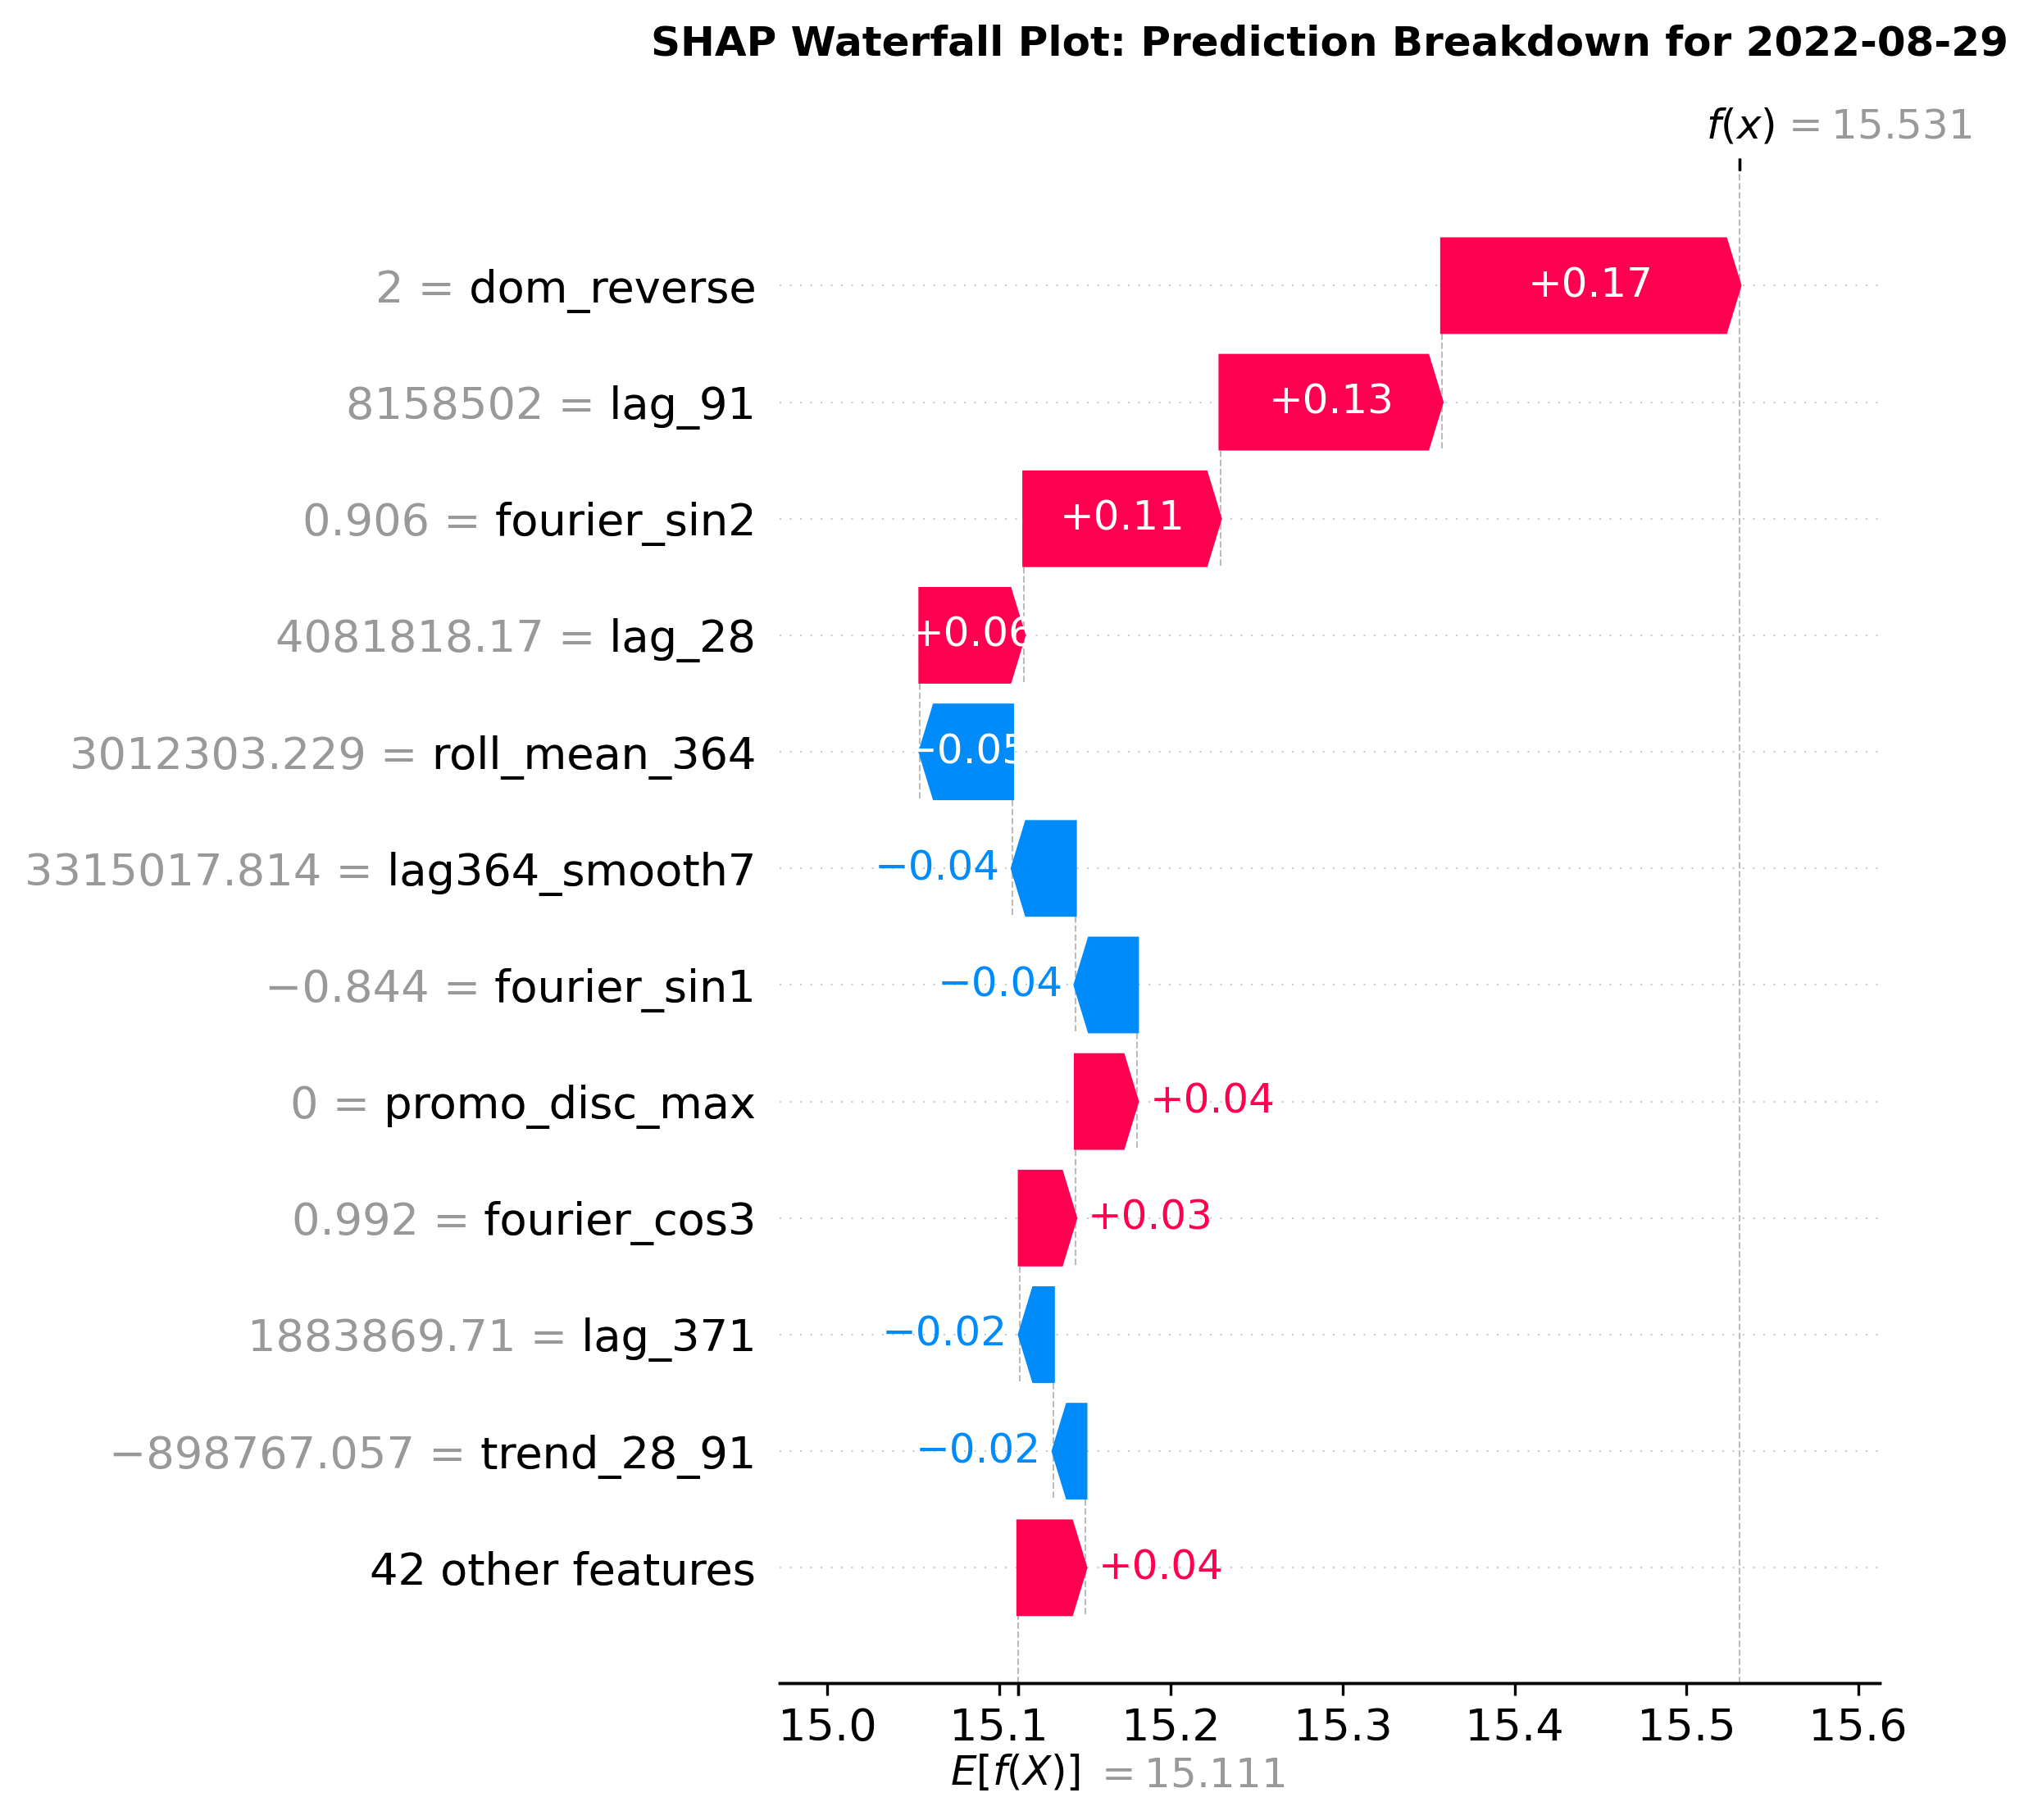

In [67]:
import matplotlib.pyplot as plt
import shap

single_explanation = shap.Explanation(
    values=shap_values[index],
    base_values=base_value,
    data=test[features].iloc[index].values,
    feature_names=features,
)

plt.figure(figsize=(10, 6), dpi=300)
shap.plots.waterfall(single_explanation, max_display=12, show=False)
plt.title(
    f"SHAP Waterfall Plot: Prediction Breakdown for {target_date}",
    fontsize=12,
    pad=15,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("shap_waterfall_2022_08_29.png", bbox_inches="tight", dpi=300)
plt.show()

In [68]:
print(f"\n  Additive Reconstruction: Base {base_value:.4f} "
      f"+ Positive Forces {push_up.sum():+.4f} "
      f"+ Negative Forces {pull_down.sum():+.4f}")
print(f"  Sum: {base_value + contribution.sum():.4f} (Log Scale) "
      f"-> Inverse Log Transformed: {predicted:,.0f} revenue units")
print(f"  Actual Value: {actual:,.0f} revenue units "
      f"| Under-prediction Error: {100 * (1 - predicted / actual):.1f}%")

R["local"] = {
    "date": target_date,
    "base_value": base_value,
    "predicted_log": float(base_value + contribution.sum()),
    "predicted": predicted,
    "actual": actual,
    "error_pct": float(100 * (predicted / actual - 1)),
    "push_up": {k: float(push_up[k]) for k in push_up.head(TOP_N).index},
    "push_up_total": float(push_up.sum()),
    "pull_down": {k: float(pull_down[k]) for k in pull_down.head(TOP_N).index},
    "pull_down_total": float(pull_down.sum()),
    "n_push_up": int(len(push_up)),
    "n_pull_down": int(len(pull_down))
}

save_results("07_explain", R)


  Additive Reconstruction: Base 15.1111 + Positive Forces +0.6653 + Negative Forces -0.2453
  Sum: 15.5311 (Log Scale) -> Inverse Log Transformed: 5,559,967 revenue units
  Actual Value: 7,928,797 revenue units | Under-prediction Error: 29.9%
